In [1]:
import pandas as pd
from sqlalchemy import create_engine

In [6]:
df=pd.read_csv('/Users/krishgupta/Data Analyst/ecommerce-sales-dashboard/data/superstore.csv',encoding='latin1')
df.columns=df.columns.str.lower().str.replace(' ','_')
df['order_date']=pd.to_datetime(df['order_date'])
df['ship_date']=pd.to_datetime(df['ship_date'])

In [7]:
df['profit_margin']=df['profit']/df['sales']
df['ship_lag_days']   = (df['ship_date'] - df['order_date']).dt.days
df['order_year']      = df['order_date'].dt.year
df['order_month']     = df['order_date'].dt.month
df['order_quarter']   = df['order_date'].dt.quarter

In [9]:
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())
print(df[['sales','profit','discount']].describe())
print(f'Negative profit rows: {(df["profit"] < 0).sum()}')

(9994, 26)
row_id                    int64
order_id                    str
order_date       datetime64[us]
ship_date        datetime64[us]
ship_mode                   str
customer_id                 str
customer_name               str
segment                     str
country                     str
city                        str
state                       str
postal_code               int64
region                      str
product_id                  str
category                    str
sub-category                str
product_name                str
sales                   float64
quantity                  int64
discount                float64
profit                  float64
profit_margin           float64
ship_lag_days             int64
order_year                int32
order_month               int32
order_quarter             int32
dtype: object
row_id           0
order_id         0
order_date       0
ship_date        0
ship_mode        0
customer_id      0
customer_name    0
segment   

In [11]:
engine=create_engine('sqlite:///superstore.db')
df.to_sql('orders', engine, if_exists='replace', index=False)
print('Database created: superstore.db')


Database created: superstore.db


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


# ---CHART 1: Monthly revenue time-series---

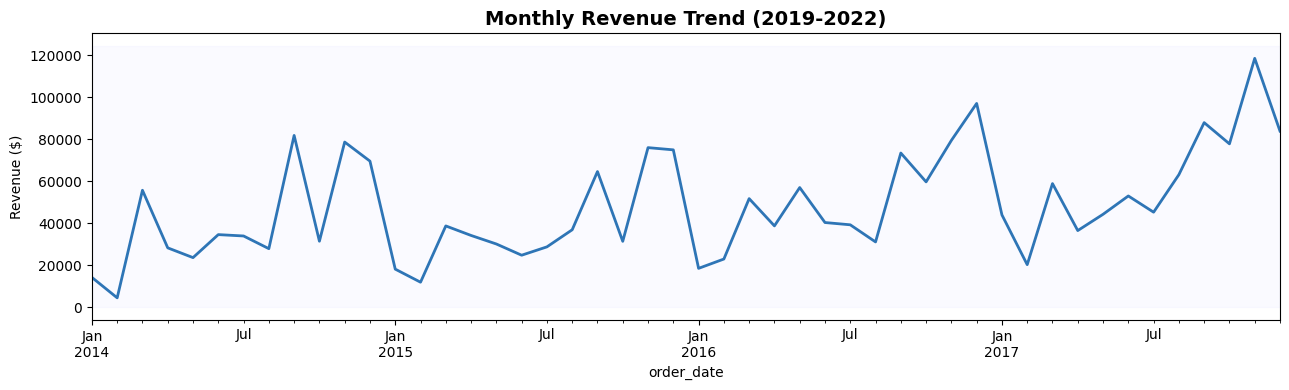

In [14]:
monthly = df.groupby(df['order_date'].dt.to_period('M'))['sales'].sum()
fig, ax= plt.subplots(figsize=(13,4))
monthly.plot(ax=ax,color='#2E75B6',linewidth=2)
ax.set_title('Monthly Revenue Trend (2019-2022)', fontsize=14, fontweight='bold')
ax.set_ylabel('Revenue ($)')
ax.axhspan(0, ax.get_ylim()[1], alpha=0.02, color='blue')
plt.tight_layout()
plt.savefig('/Users/krishgupta/Data Analyst/ecommerce-sales-dashboard/dashboard/screenshots/monthly_trend.png',dpi=150)
plt.show()

# ---Chart 2: Profit margin by sub-category (sorted)---

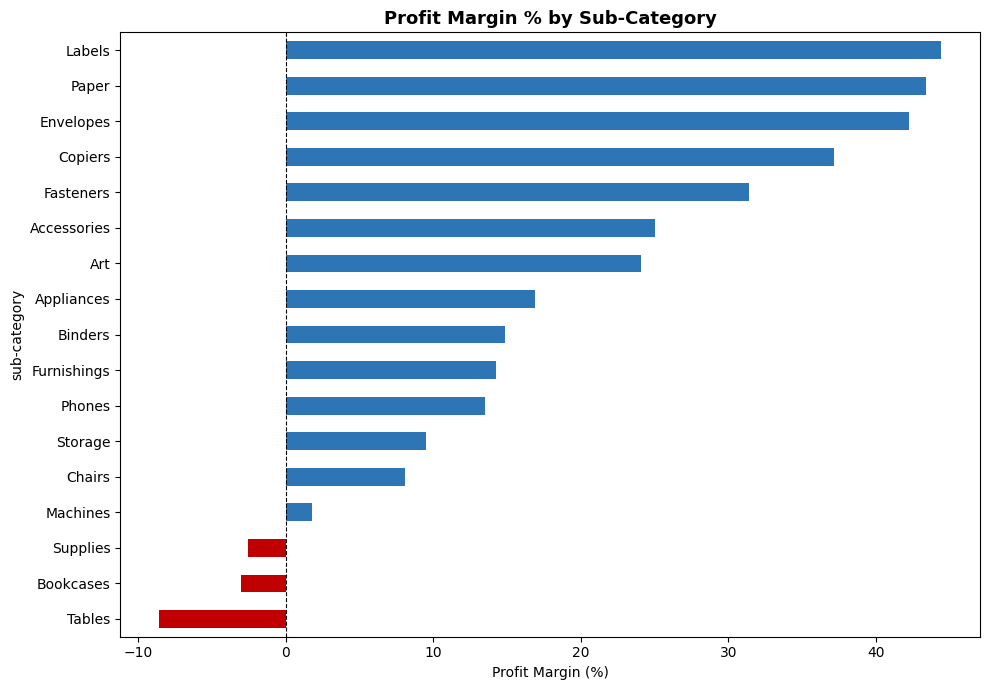

In [16]:
sub = df.groupby('sub-category').agg(
    revenue=('sales','sum'), profit=('profit','sum')
).assign(margin=lambda x: x['profit']/x['revenue']*100).sort_values('margin')

colors = ['#C00000' if m < 0 else '#2E75B6' for m in sub['margin']]
sub['margin'].plot(kind='barh', color=colors, figsize=(10, 7))
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Profit Margin % by Sub-Category', fontsize=13, fontweight='bold')
plt.xlabel('Profit Margin (%)')
plt.tight_layout()
plt.savefig('/Users/krishgupta/Data Analyst/ecommerce-sales-dashboard/dashboard/screenshots/subcategory_margins.png', dpi=150)
plt.show()

# ---Chart 3: Discount vs profit scatter---

FileNotFoundError: [Errno 2] No such file or directory: 'dashboard/screenshots/chart3_discount_scatter.png'

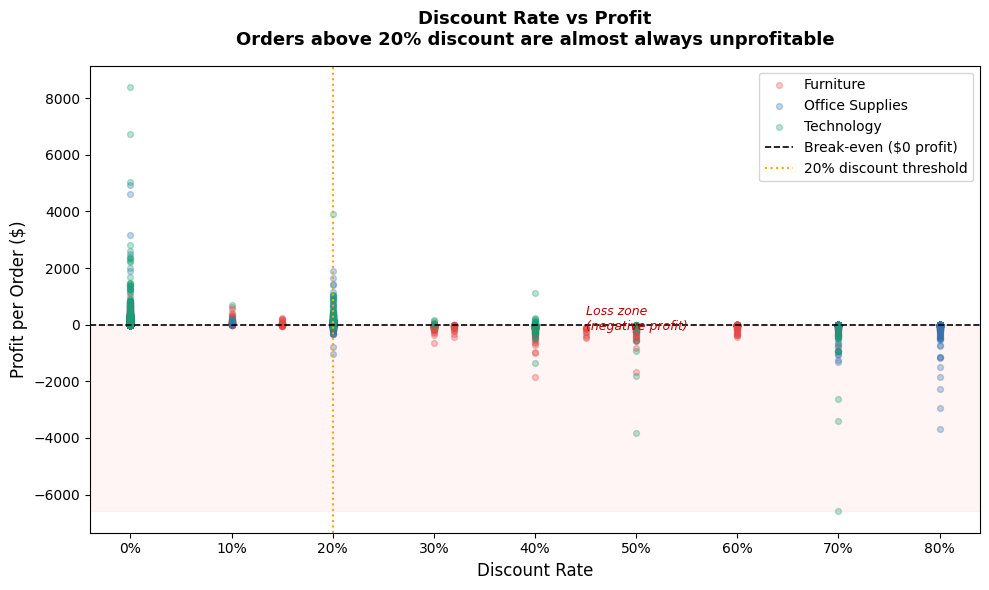

In [ ]:
import matplotlib.ticker as mtick
import numpy as np

fig, ax = plt.subplots(figsize=(10, 6))

# Colour points by category
categories = df['category'].unique()
colors = {'Furniture': '#E24B4A', 'Office Supplies': '#2E75B6', 'Technology': '#1D9E75'}

for cat in categories:
    subset = df[df['category'] == cat]
    ax.scatter(subset['discount'], subset['profit'],
               alpha=0.3, s=18,
               color=colors[cat],
               label=cat)

# Break-even line
ax.axhline(0, color='black', linestyle='--', linewidth=1.2, label='Break-even ($0 profit)')

# Shade the loss zone
ax.axhspan(df['profit'].min(), 0, alpha=0.04, color='red')

# 20% discount danger threshold
ax.axvline(0.20, color='orange', linestyle=':', linewidth=1.5, label='20% discount threshold')

ax.set_xlabel('Discount Rate', fontsize=12)
ax.set_ylabel('Profit per Order ($)', fontsize=12)
ax.set_title('Discount Rate vs Profit\nOrders above 20% discount are almost always unprofitable',
             fontsize=13, fontweight='bold', pad=15)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
ax.legend(fontsize=10)

# Annotation
ax.annotate('Loss zone\n(negative profit)',
            xy=(0.45, -200), fontsize=9, color='#C00000',
            fontstyle='italic')

plt.tight_layout()
plt.savefig('/Users/krishgupta/Data Analyst/ecommerce-sales-dashboard/dashboard/screenshots/chart3_discount_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

# Print the key stat this chart is proving
discount_20_plus = df[df['discount'] > 0.20]
print(f"Orders with >20% discount: {len(discount_20_plus)} ({len(discount_20_plus)/len(df)*100:.1f}% of all orders)")
print(f"Average profit on those orders: ${discount_20_plus['profit'].mean():.2f}")
print(f"Total profit destroyed: ${discount_20_plus['profit'].sum():.2f}")